In [1]:
import numpy as np
import matplotlib.pyplot as plt

from astropy import units as u
from astropy.time import Time
from astropy.coordinates import get_body_barycentric_posvel
from astropy.coordinates import HeliocentricMeanEcliptic, ICRS, CartesianRepresentation

from poliastro.bodies import Sun, Earth, Mars
from poliastro.iod import izzo

In [2]:
launch_start  = Time("2028-09-01", scale="tdb")
launch_end    = Time("2029-04-01", scale="tdb")
arrival_start = Time("2029-03-01", scale="tdb")
arrival_end   = Time("2030-02-01", scale="tdb")

N_launch  = 60
N_arrival = 60

launch_dates  = launch_start  + (launch_end  - launch_start)  * np.linspace(0, 1, N_launch)
arrival_dates = arrival_start + (arrival_end - arrival_start) * np.linspace(0, 1, N_arrival)

print("launch_dates[0]: ",  launch_dates[0].iso)
print("launch_dates[-1]:", launch_dates[-1].iso)
print("arrival_dates[0]: ", arrival_dates[0].iso)
print("arrival_dates[-1]:", arrival_dates[-1].iso)

launch_dates[0]:  2028-09-01 00:00:00.000
launch_dates[-1]: 2029-04-01 00:00:00.000
arrival_dates[0]:  2029-03-01 00:00:00.000
arrival_dates[-1]: 2030-02-01 00:00:00.000


In [3]:
# And make sure your sweep uses the fixed functions:
mu_sun = Sun.k.to(u.km**3 / u.s**2)

OBLIQUITY = np.radians(23.439)
ROT = np.array([
    [1,              0,               0],
    [0,  np.cos(OBLIQUITY), np.sin(OBLIQUITY)],
    [0, -np.sin(OBLIQUITY), np.cos(OBLIQUITY)]
])

def get_body_state(body_name, time):
    r_body, v_body = get_body_barycentric_posvel(body_name, time)
    r_sun,  v_sun  = get_body_barycentric_posvel("sun", time)
    r_eq = (r_body.xyz - r_sun.xyz).to(u.km).value
    v_eq = (v_body.xyz - v_sun.xyz).to(u.km / u.s).value
    return (ROT @ r_eq) * u.km, (ROT @ v_eq) * (u.km / u.s)

C3       = np.full((N_launch, N_arrival), np.nan)
vinf_arr = np.full((N_launch, N_arrival), np.nan)
TOF      = np.full((N_launch, N_arrival), np.nan)

for i, t_launch in enumerate(launch_dates):
    r1, v1_earth = get_body_state("earth", t_launch)
    for j, t_arrival in enumerate(arrival_dates):
        if t_arrival <= t_launch:
            continue
        tof = (t_arrival - t_launch).to(u.s)
        r2, v2_mars = get_body_state("mars", t_arrival)
        try:
            v1_sc, v2_sc = next(izzo.lambert(mu_sun, r1, r2, tof, M=0))
        except Exception:
            continue
        dv1 = v1_sc - v1_earth
        dv2 = v2_sc - v2_mars
        C3[i, j]       = float(np.linalg.norm(dv1.value)**2)
        vinf_arr[i, j] = float(np.linalg.norm(dv2.value))
        TOF[i, j]      = float(tof.to(u.day).value)

print(f"Valid cells : {np.sum(~np.isnan(C3))} / {N_launch * N_arrival}")
print(f"C3  min/max : {np.nanmin(C3):.1f} / {np.nanmax(C3):.1f} km²/s²")
print(f"TOF min/max : {np.nanmin(TOF):.0f} / {np.nanmax(TOF):.0f} days")

Valid cells : 3569 / 3600
C3  min/max : 9.0 / 15737258.8 km²/s²
TOF min/max : 1 / 518 days


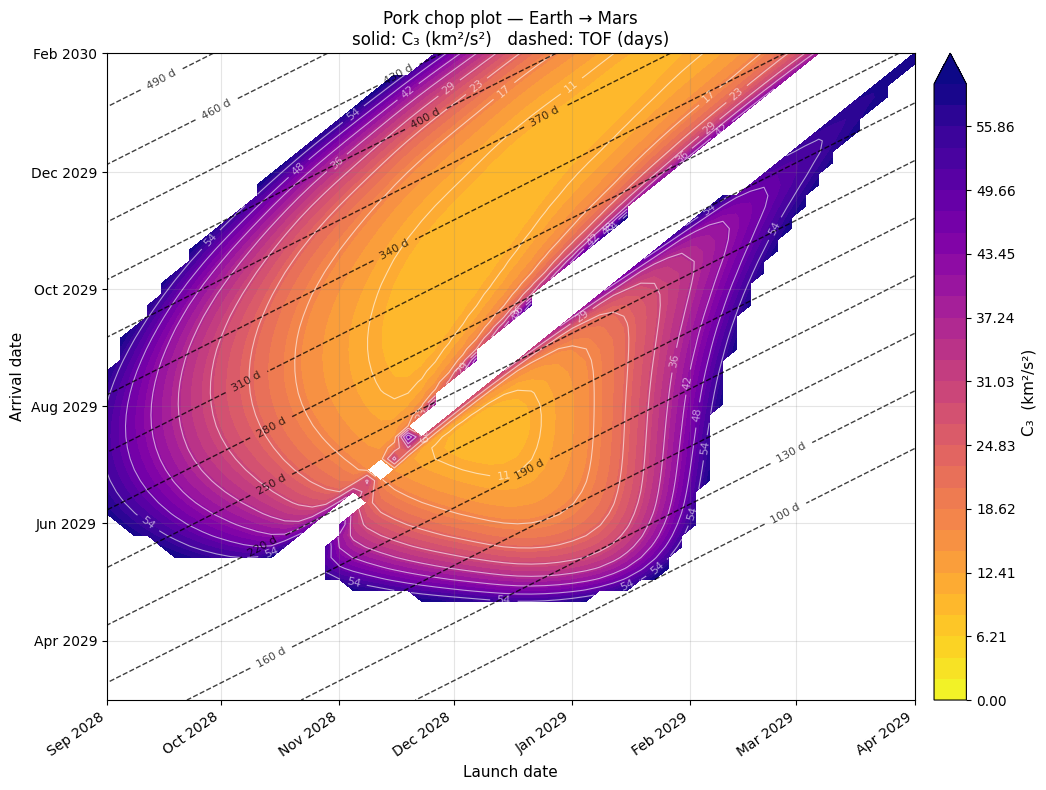

In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import BoundaryNorm
import numpy as np

# ── Clip C3 to a readable range ───────────────────────────────────────
C3_MAX = 60.0   # km²/s² — adjust if your min C3 is higher
C3_plot = np.where((C3 > C3_MAX) | np.isnan(C3), np.nan, C3)

# ── Build date axes ───────────────────────────────────────────────────
import matplotlib.dates as mdates
launch_dts  = [t.to_datetime() for t in launch_dates]
arrival_dts = [t.to_datetime() for t in arrival_dates]
L, A = np.meshgrid(mdates.date2num(launch_dts),
                   mdates.date2num(arrival_dts), indexing='ij')

# ── Plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 8))

# Filled C3 background
levels_fill = np.linspace(0, C3_MAX, 30)
cf = ax.contourf(L, A, C3_plot, levels=levels_fill,
                 cmap='plasma_r', extend='max')
cbar = plt.colorbar(cf, ax=ax, pad=0.02)
cbar.set_label('C₃  (km²/s²)', fontsize=11)

# Solid C3 contour lines + labels
c3_line_levels = np.linspace(5, C3_MAX, 10)
cs = ax.contour(L, A, C3_plot, levels=c3_line_levels,
                colors='white', linewidths=0.8, alpha=0.6)
ax.clabel(cs, fmt='%.0f', fontsize=8, inline=True)

# Dashed TOF contour lines + labels
tof_levels = np.arange(100, int(np.nanmax(TOF)) + 1, 30)
tof_cs = ax.contour(L, A, TOF, levels=tof_levels,
                    colors='black', linewidths=1.0,
                    linestyles='dashed', alpha=0.75)
ax.clabel(tof_cs, fmt='%d d', fontsize=8, inline=True)

# ── Format axes as calendar dates ─────────────────────────────────────
ax.xaxis_date()
ax.yaxis_date()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.yaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.yaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.autofmt_xdate(rotation=35)

ax.set_xlabel('Launch date', fontsize=11)
ax.set_ylabel('Arrival date', fontsize=11)
ax.set_title('Pork chop plot — Earth → Mars\n'
             'solid: C₃ (km²/s²)   dashed: TOF (days)',
             fontsize=12)
ax.grid(color='gray', alpha=0.2)

plt.tight_layout()
# plt.savefig('pork_chop.png', dpi=150, bbox_inches='tight')
plt.show()